# Student Performance Indicator

### Life cycle of Machine learnng project


+ Understand the Problem Statement
+ Data Collection
+ Data Checks to perform
+ Exploratory data analysis
+ Data Pre-Processing
+ Model Training
+ Choose best model

### 1) Problem Statement

+ This project understands how the student's performance (test scores) is affected by other features such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

### 2) Data Collection

+ Data source - Kaggle
+ The data consists of 8 columns and 1000 rows

#### 2.1) Import Data and Required Packages

##### Importing Numpy, Pandas, Seaborn, Matplotlib and Warningd Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

##### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv(r"c:\Users\Programming\Datasets\students.csv")

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

### 2.2) Datasets Info

In [5]:
print(f"Gender:",df['gender'].unique().to_numpy())
print(f"Race:",df['race_ethnicity'].unique().to_numpy())
print(f"parental_level_of_education:",df['parental_level_of_education'].unique().to_numpy())
print(f"lunch:",df['lunch'].unique().to_numpy())
print(f"test_preparation_course:",df['test_preparation_course'].unique().to_numpy())

Gender: ['female' 'male']
Race: ['group B' 'group C' 'group A' 'group D' 'group E']
parental_level_of_education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch: ['standard' 'free/reduced']
test_preparation_course: ['none' 'completed']


### 3) Data checks

+ Missing values
+ Duplicates
+ Data types
+ Statistcs
+ Various categories present in the different categorical column

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 3.7) Exploring Data

In [11]:
print("Categories in Gender Variable:", end=" ")
print(df['gender'].unique().to_numpy())

print("==="*30)

print("Categories in Race Ethnicity Variable:", end=" ")
print(df['race_ethnicity'].unique().to_numpy())

print("==="*30)

print("Categories in Parental_Level_of_Education Variable:", end=" ")
print(df['parental_level_of_education'].unique().to_numpy())

print("==="*30)

print("Categories in lunch Variable:", end=" ")
print(df['lunch'].unique().to_numpy())

print("==="*30)

print("Categories in Test_Preparation_Course Variable:", end=" ")
print(df['test_preparation_course'].unique().to_numpy())


Categories in Gender Variable: ['female' 'male']
Categories in Race Ethnicity Variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in Parental_Level_of_Education Variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in lunch Variable: ['standard' 'free/reduced']
Categories in Test_Preparation_Course Variable: ['none' 'completed']


In [12]:
columns = df.columns
for feature in columns:
    if df[feature].dtype != 'O':
        print(f"Numeric feature:", feature)

Numeric feature: gender
Numeric feature: race_ethnicity
Numeric feature: parental_level_of_education
Numeric feature: lunch
Numeric feature: test_preparation_course
Numeric feature: math_score
Numeric feature: reading_score
Numeric feature: writing_score


In [13]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [14]:
from pandas.api.types import is_numeric_dtype

numerical_features = [col for col in df.columns if is_numeric_dtype(df[col])]
categorical_features = [col for col in df.columns if not is_numeric_dtype(df[col])]

print("We have {} numerical features: {}".format(len(numerical_features), numerical_features))
print("We have {} categorical features: {}".format(len(categorical_features), categorical_features))
    
        

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


## Feature Engineering

In [15]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3

In [16]:
math_score = df[df['math_score']==100]['average_score'].count()
reading_score = df[df['reading_score']==100]['average_score'].count()
writing_score = df[df['writing_score']==100]['average_score'].count()

print(f'Number of students with full marks in maths: {math_score}')
print(f'Number of students with full marks in reading: {reading_score}')
print(f'Number of students with full marks in writing: {writing_score}')

Number of students with full marks in maths: 7
Number of students with full marks in reading: 17
Number of students with full marks in writing: 14


In [17]:
maths_score_less_20 = df[df['math_score'] <= 20]['average_score'].count()
reading_score_less_20 = df[df['reading_score'] <= 20]['average_score'].count()
writing_score_less_20 = df[df['writing_score'] <= 20]['average_score'].count()

print(f'Number of students with less than 20 marks in maths:', maths_score_less_20)
print(f'Number of students with less than 20 marks in reading:', reading_score_less_20)
print(f'Number of students with less than 20 marks in writng:', writing_score_less_20)

Number of students with less than 20 marks in maths: 4
Number of students with less than 20 marks in reading: 1
Number of students with less than 20 marks in writng: 3


### Insights

+ From above valus we getstudents have performed the worst in maths
 + The best performance is in reading section

## 4) Data Exploration( Visualization)

#### 4.1 Visualize average score distribution to make some conclusion

+ Histogram
+ Kernel Distribution Function (KDE)

##### 4.1.1 Histogram & KDE

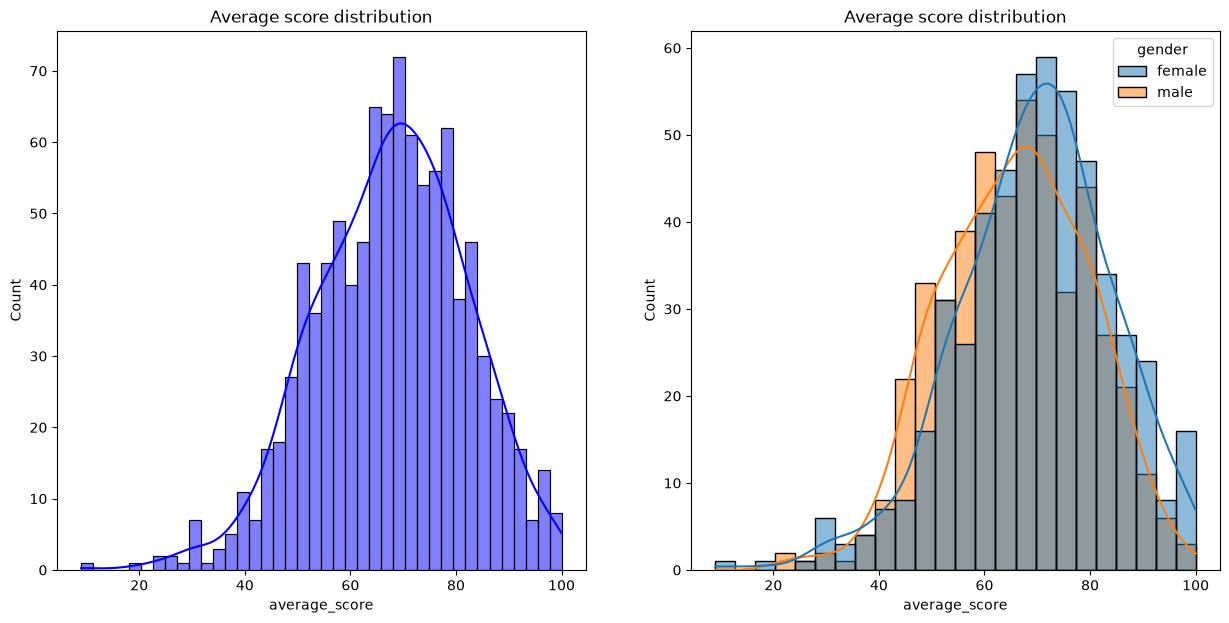

In [18]:
fig, axs = plt.subplots(1,2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data=df, x = 'average_score', bins = 40, kde = True, color = 'blue')
plt.title("Average score distribution")
plt.ylabel('Count')
plt.subplot(122)
sns.histplot(data=df, x = 'average_score', kde = True, hue = 'gender')
plt.title("Average score distribution")
plt.ylabel('Count')
plt.show()

#### Female students tends to perform better than male students

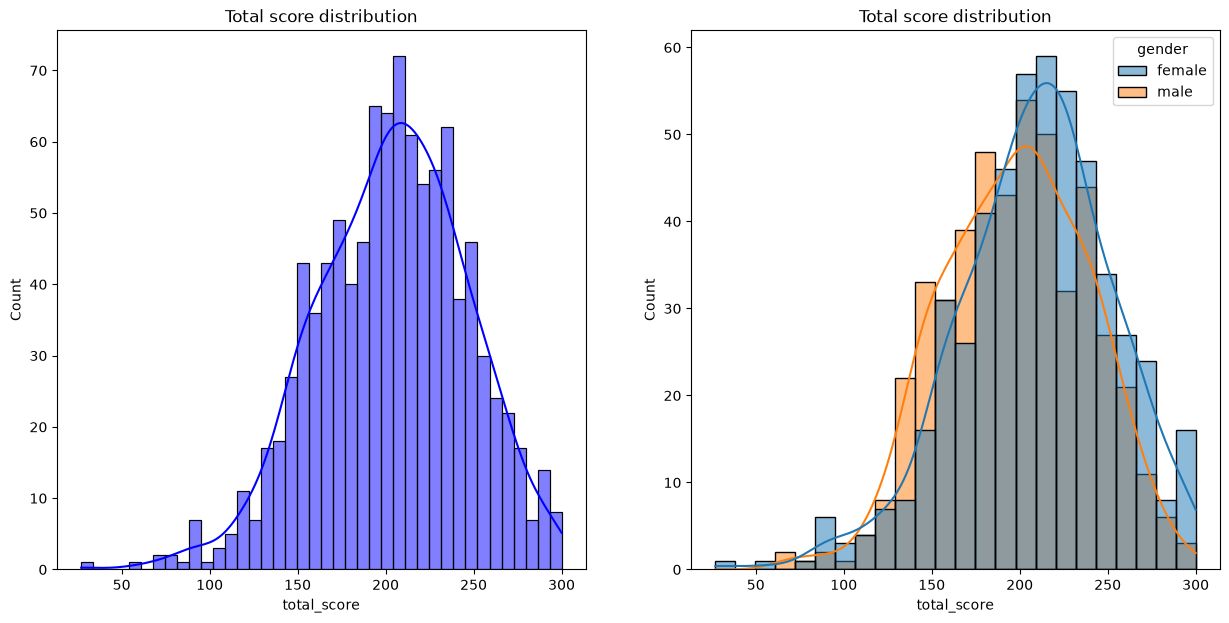

In [19]:
fig, axs = plt.subplots(1,2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data=df, x = 'total_score', bins = 40, kde = True, color = 'blue')
plt.title("Total score distribution")
plt.ylabel('Count')
plt.subplot(122)
sns.histplot(data=df, x = 'total_score', kde = True, hue = 'gender')
plt.title("Total score distribution")
plt.ylabel('Count')
plt.show()

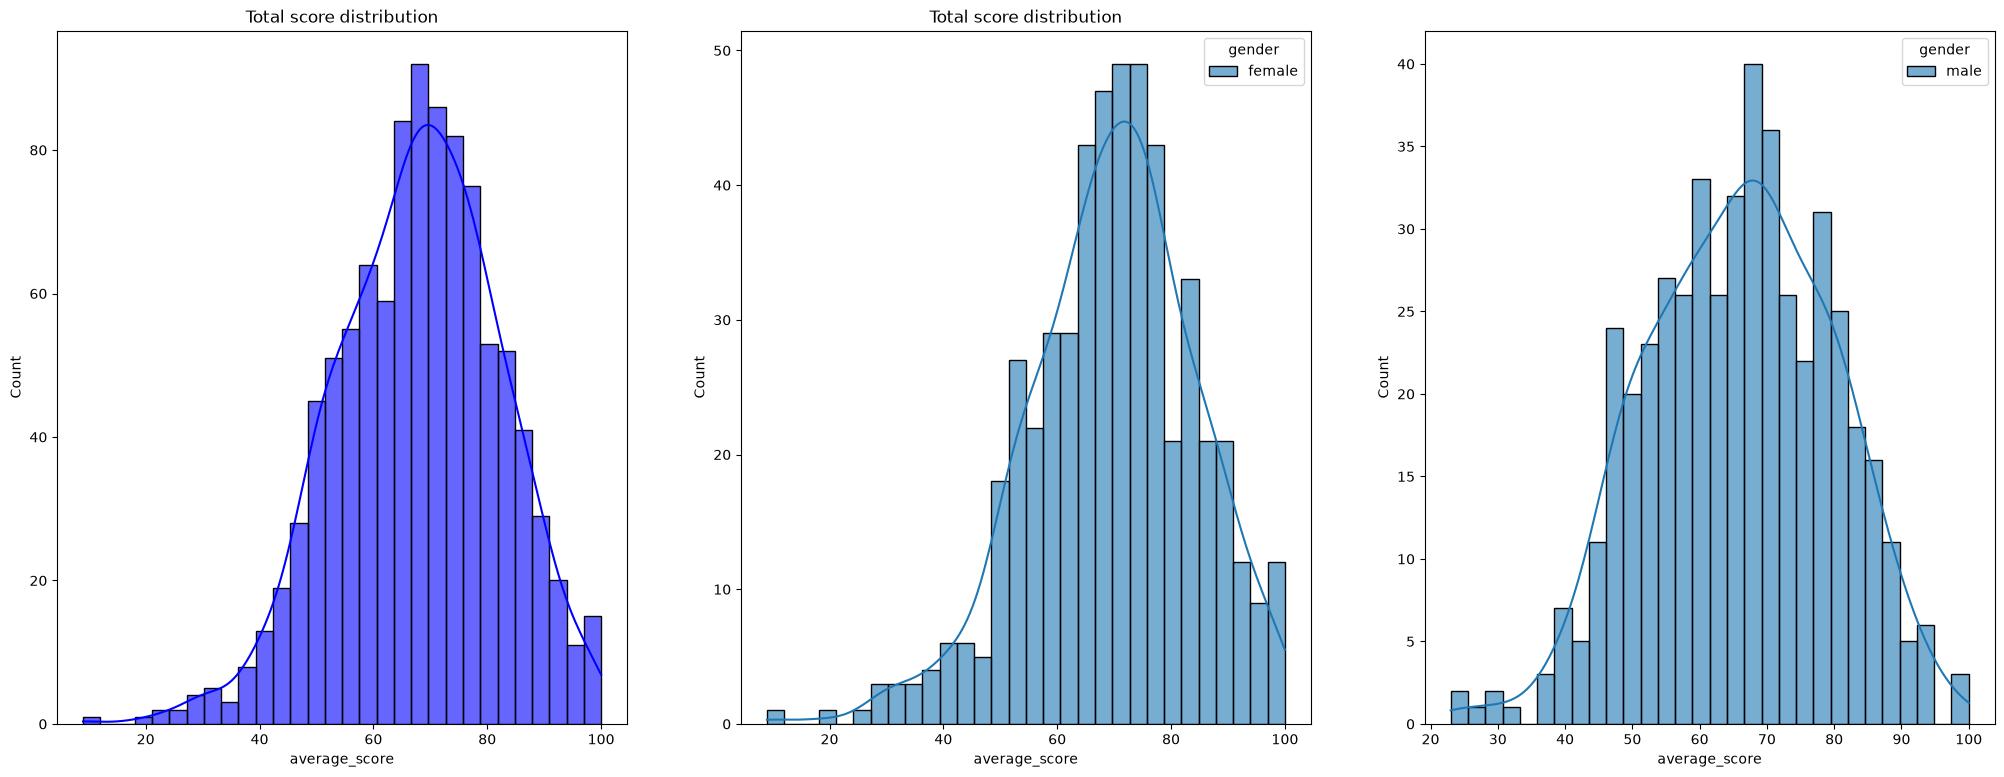

In [20]:
fig, axs = plt.subplots(1,3, figsize = (25, 9))
plt.subplot(131)
sns.histplot(data=df, x = 'average_score', bins = 30, kde = True, color = 'blue', alpha = 0.6)
plt.title("Total score distribution")
plt.ylabel('Count')
plt.subplot(132)
sns.histplot(data=df[df.gender == 'female'], x = 'average_score', bins = 30, kde = True, hue = 'gender', alpha = 0.6)
plt.title("Total score distribution")
plt.ylabel('Count')
plt.subplot(133)
sns.histplot(data=df[df.gender == 'male'], x = 'average_score', bins = 30, kde = True, hue = 'gender', alpha = 0.6)
plt.show()

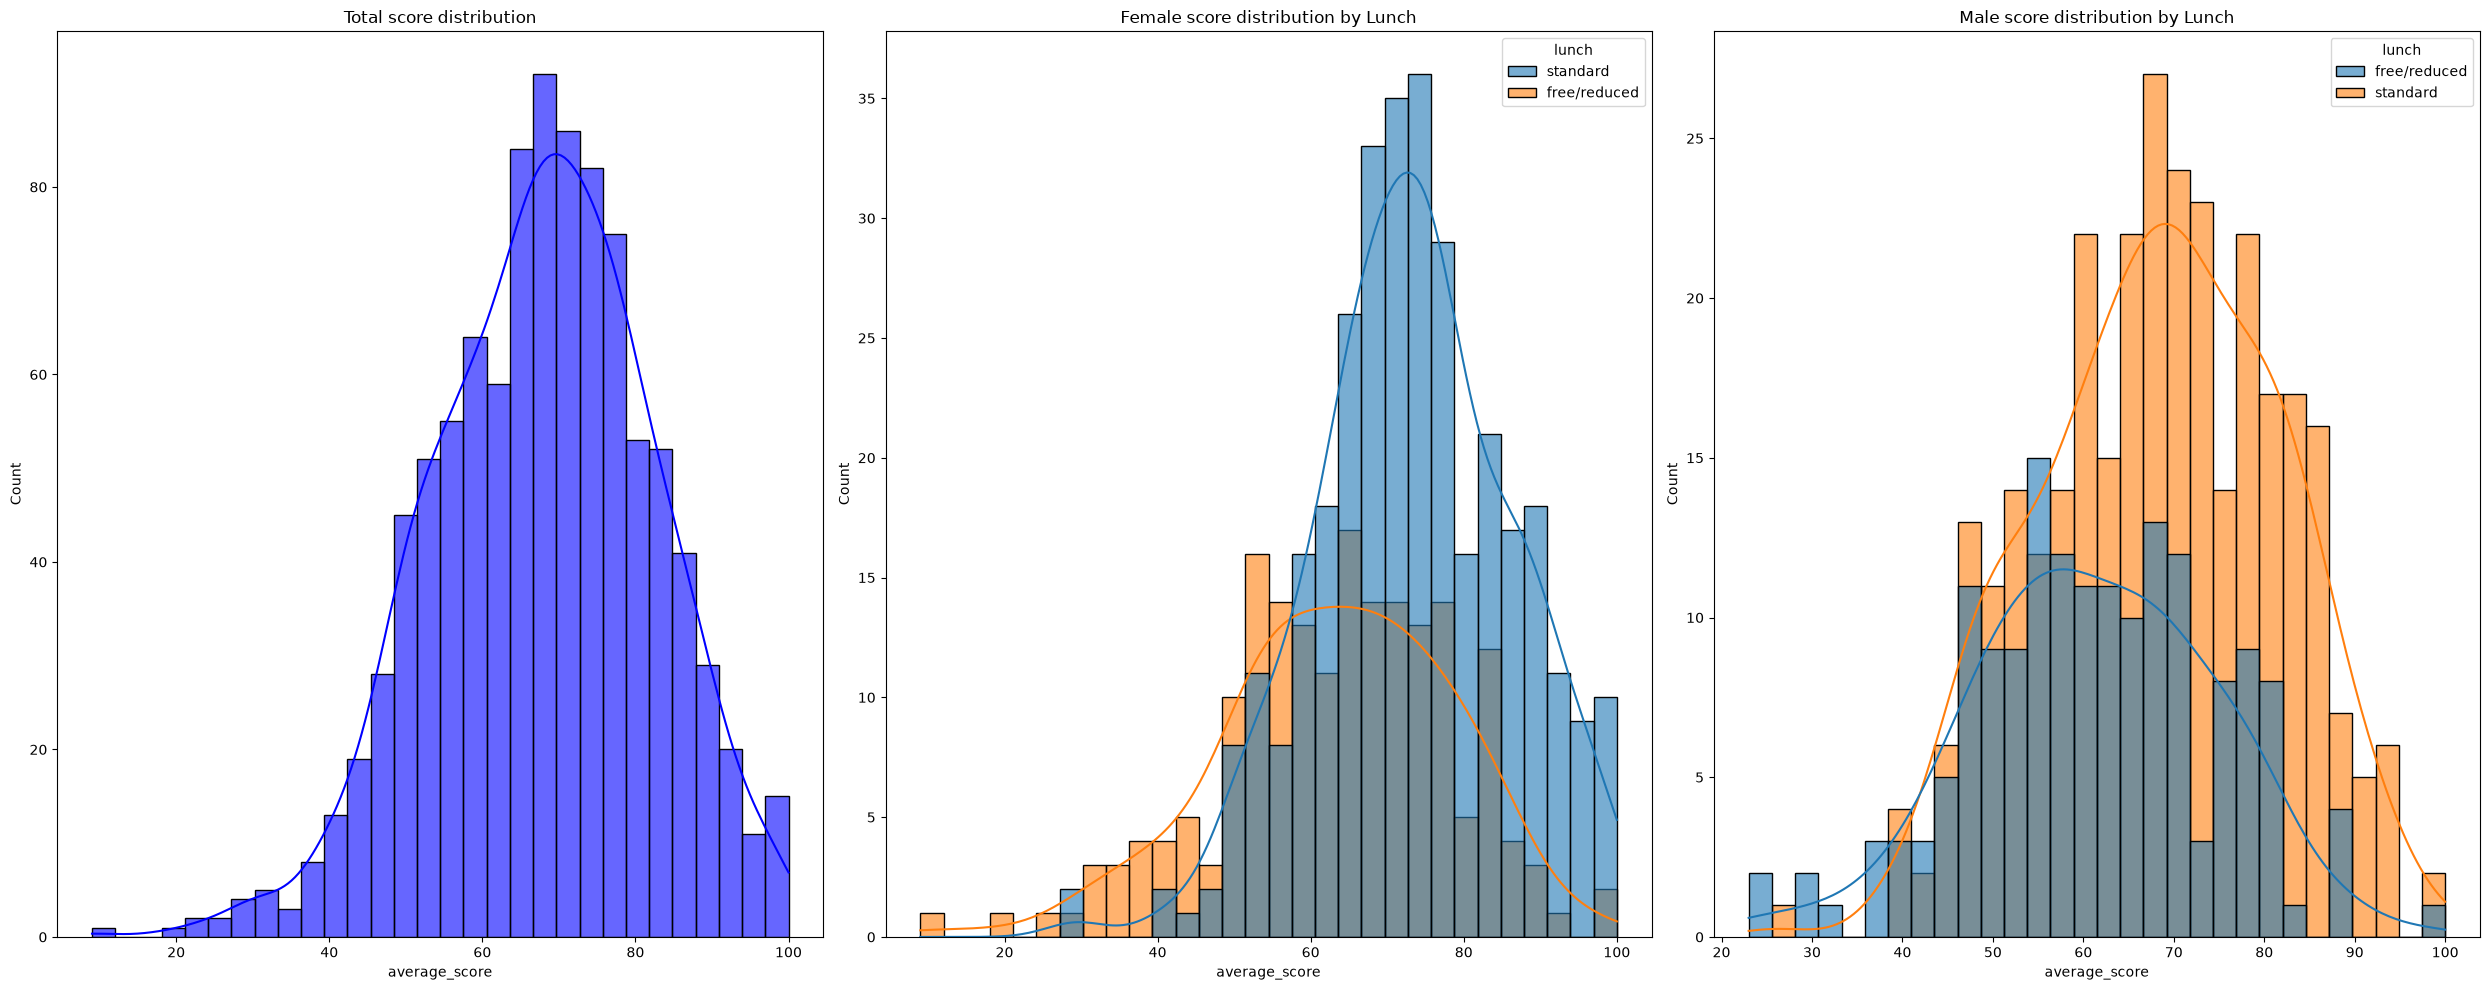

In [21]:
fig, axs = plt.subplots(1,3, figsize = (25, 10))
plt.subplot(131)
sns.histplot(data=df, x = 'average_score', bins = 30, kde = True, color = 'blue', alpha = 0.6)
axs[0].set_title("Total score distribution")
plt.subplot(132)
sns.histplot(data=df[df.gender == 'female'], x = 'average_score', bins = 30, kde = True, hue = 'lunch', alpha = 0.6)
axs[1].set_title("Female score distribution by Lunch")
plt.subplot(133)
sns.histplot(data=df[df.gender == 'male'], x = 'average_score', bins = 30, kde = True, hue = 'lunch', alpha = 0.6)
axs[2].set_title("Male score distribution by Lunch")
plt.tight_layout()
plt.show()

##### Insights
+ Students who receive standard lunch consistently outperform their peers who receive free or reduced-price lunch, regardless of gender.

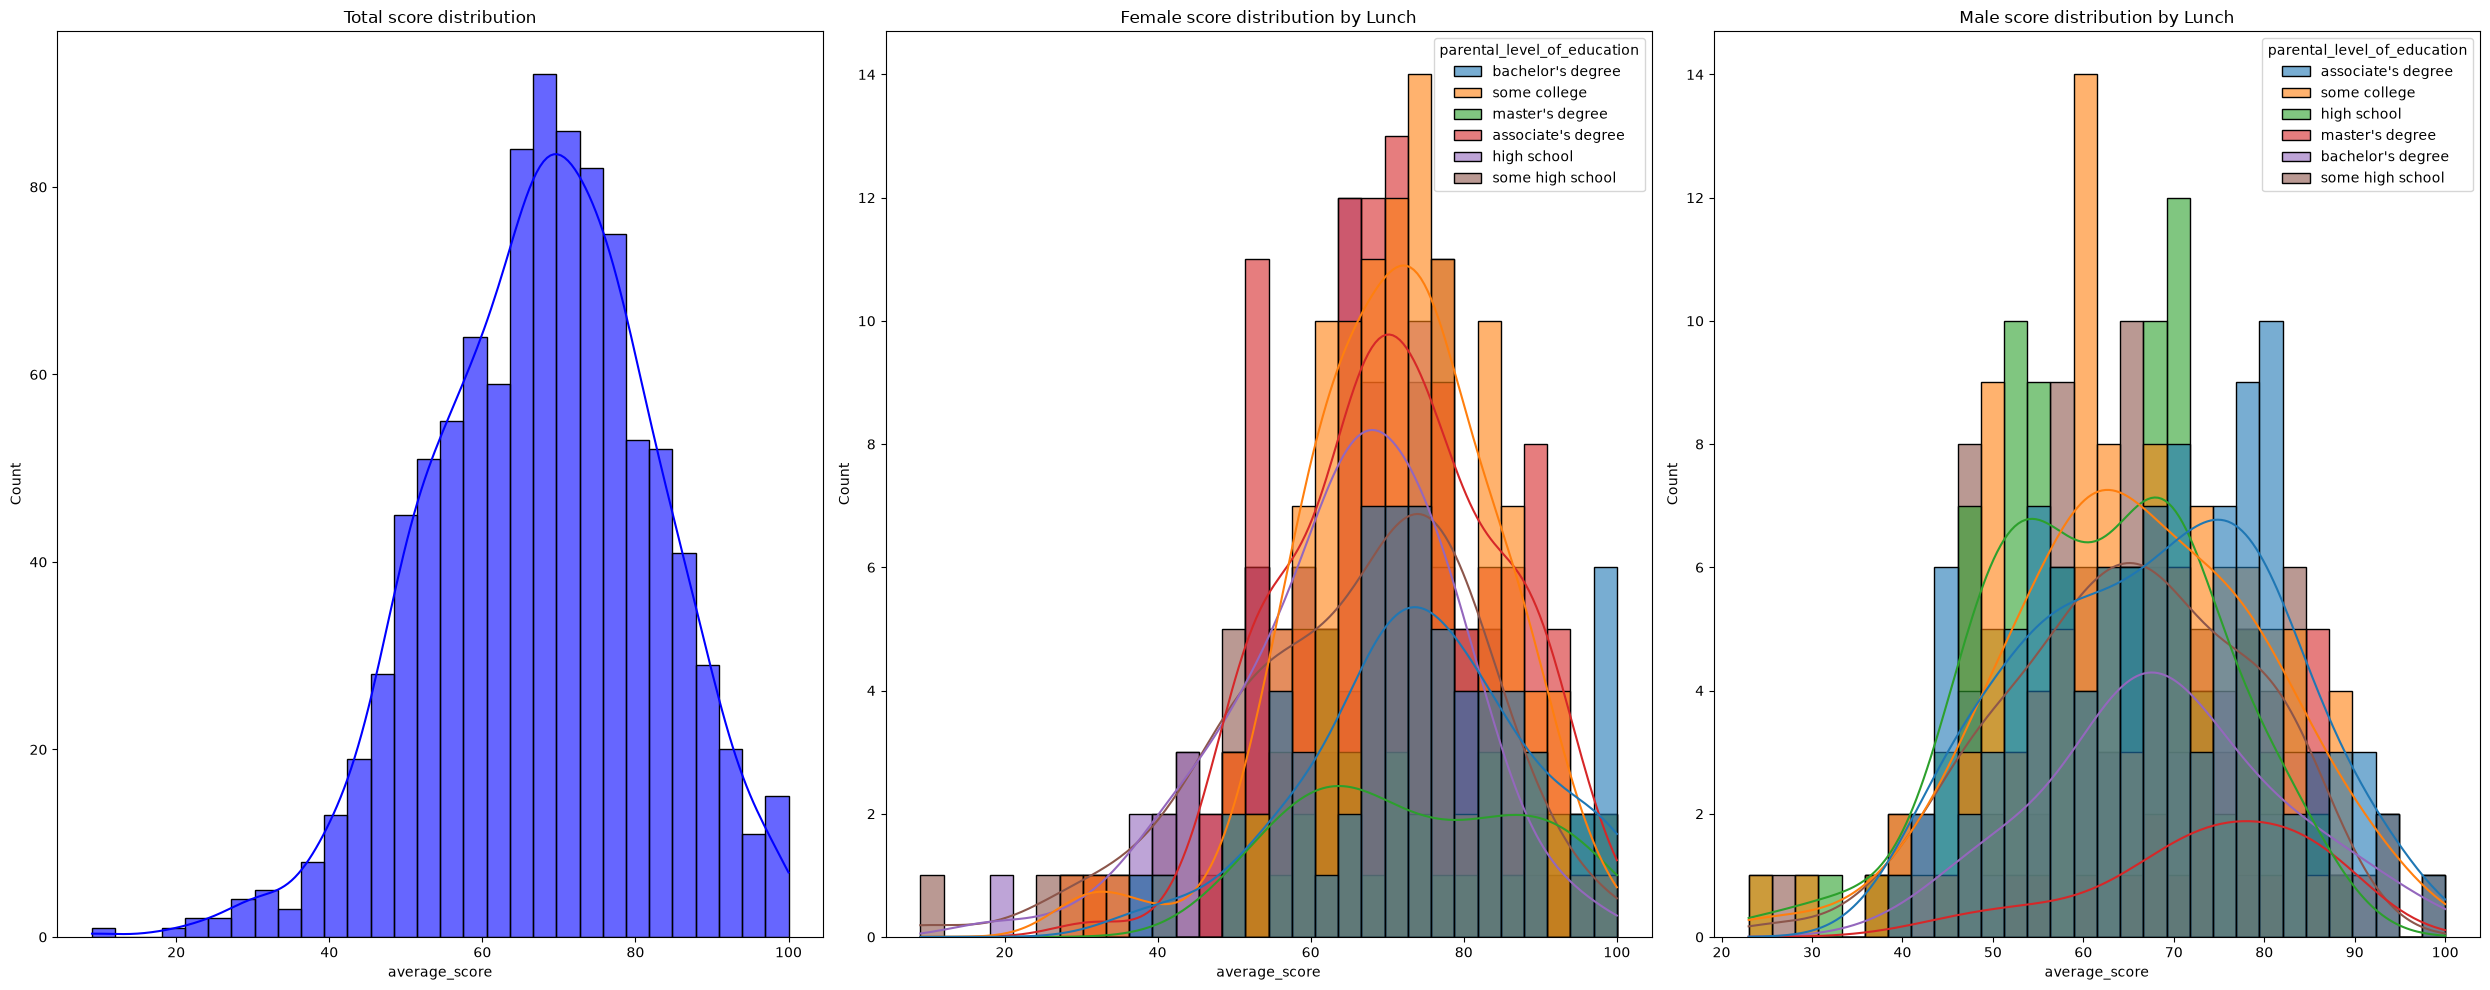

In [22]:
fig, axs = plt.subplots(1,3, figsize = (25, 10))
plt.subplot(131)
sns.histplot(data=df, x = 'average_score', bins = 30, kde = True, color = 'blue', alpha = 0.6)
axs[0].set_title("Total score distribution")
plt.subplot(132)
sns.histplot(data=df[df.gender == 'female'], x = 'average_score', bins = 30, kde = True, hue = 'parental_level_of_education', alpha = 0.6)
axs[1].set_title("Female score distribution by Lunch")
plt.subplot(133)
sns.histplot(data=df[df.gender == 'male'], x = 'average_score', bins = 30, kde = True, hue = 'parental_level_of_education', alpha = 0.6)
axs[2].set_title("Male score distribution by Lunch")
plt.tight_layout()
plt.show()

#### Insights
+ In general, parents level of educaton does not help students perform better in their exams regardless of the gender
+ 2nd plots shows that parents's whose level of educaton is of associate's degree or master's degree their male child tend to perform well in exam
+ 3rd plot we can see there is no effect of parent's education on female students

### 4.2) Maximum score of students in all three subjects

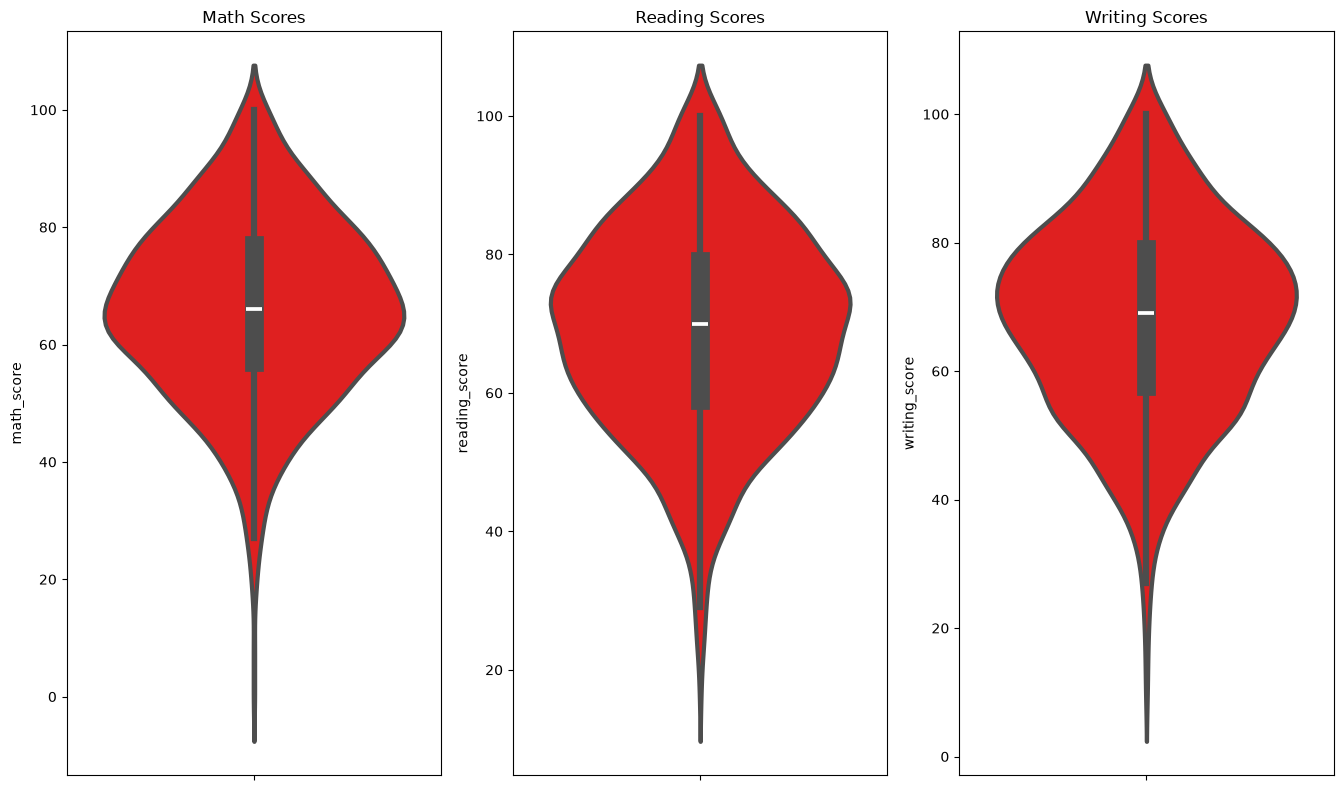

In [23]:
plt.figure(figsize = (18,8))
plt.subplot(1,4,1)
sns.violinplot(data = df, y = 'math_score', color='red', linewidth=3)
plt.title('Math Scores')
plt.subplot(1,4,2)
sns.violinplot(data = df, y = 'reading_score', color='red', linewidth=3)
plt.title('Reading Scores')
plt.subplot(1,4,3)
sns.violinplot(data = df, y = 'writing_score', color='red', linewidth=3)
plt.title('Writing Scores')
plt.tight_layout()
plt.show()

### Insights

+ It is clear that most students scores between 60 and 80 across all subjects

## 4.3) Multivariate Analysis using Pie plot

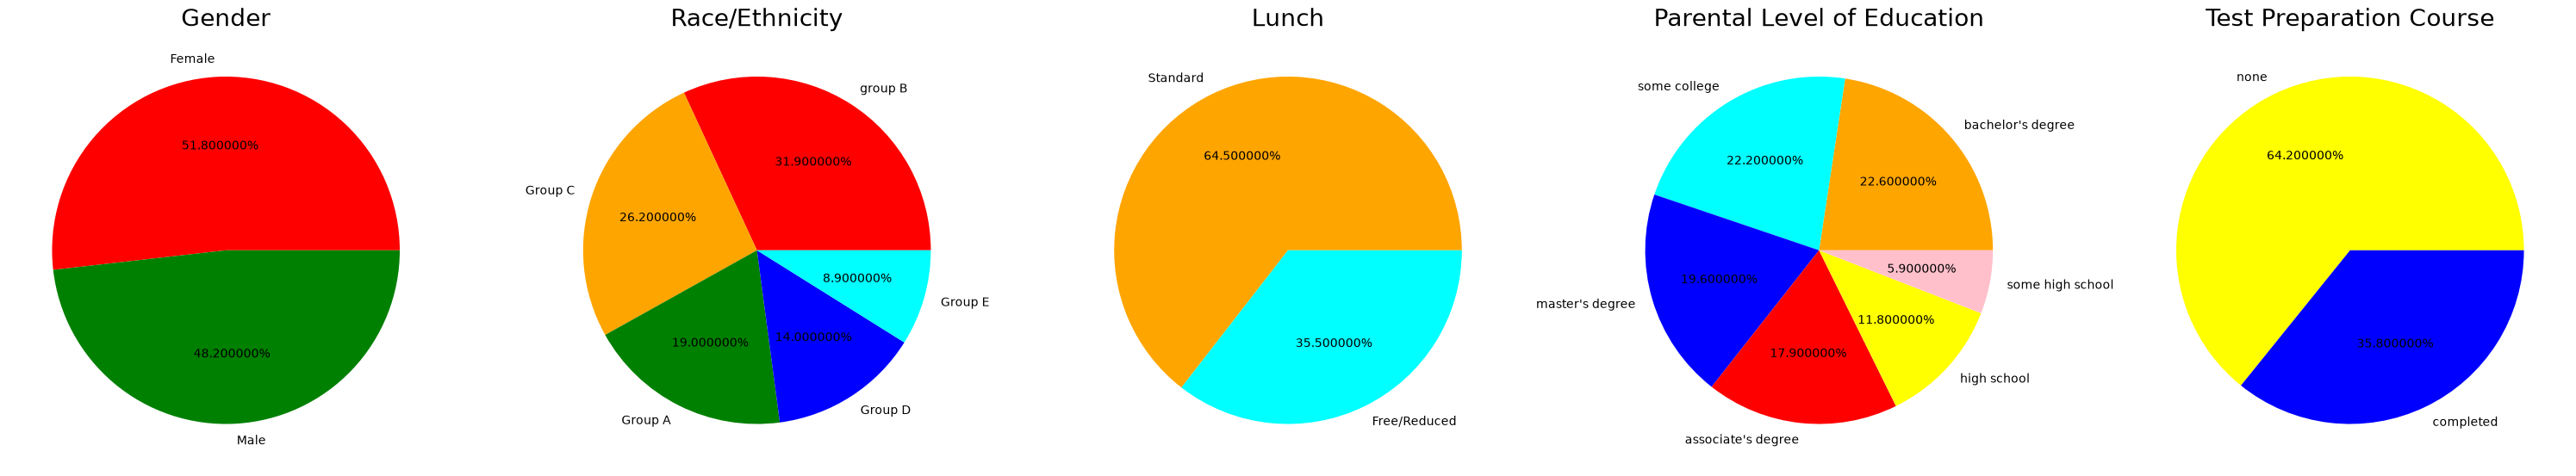

In [24]:
plt.rcParams['figure.figsize'] = (30,12)
plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='%2f%%')
plt.title("Gender", fontsize=20)
plt.axis('off')


plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels = ['group B', 'Group C', 'Group A', 'Group D', 'Group E']
color = ['red', 'orange', 'green', 'blue', 'cyan']
plt.pie(size, colors=color, labels=labels, autopct='%2f%%')
plt.title("Race/Ethnicity", fontsize=20)
plt.axis('off')

plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free/Reduced']
color = ['orange','cyan']
plt.pie(size, colors=color, labels=labels, autopct='%2f%%')
plt.title("Lunch", fontsize=20)
plt.axis('off')


plt.subplot(1,5,4)
size = df['parental_level_of_education'].value_counts()
labels = ["bachelor's degree","some college", "master's degree","associate's degree","high school", "some high school"]
color = ['orange','cyan','blue','red','yellow','pink']
plt.pie(size, colors=color, labels=labels, autopct='%2f%%')
plt.title("Parental Level of Education", fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size = df['test_preparation_course'].value_counts()
labels = ["none", "completed"]
color = ['yellow','blue']
plt.pie(size, colors=color, labels=labels, autopct='%2f%%')
plt.title("Test Preparation Course", fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()


### Insights

+ The number of female and male students is almost equal
+ The number of students are greatest in group B
+ Large number of students have not enrolled on any course

### 4.4) Feature wise visualization
##### 4.4.1) Gender Column
+ How is the distribution of gender?
+ Is gender has any effect on student's performance?

####  Univariate analysis
##### How is distribution of gender

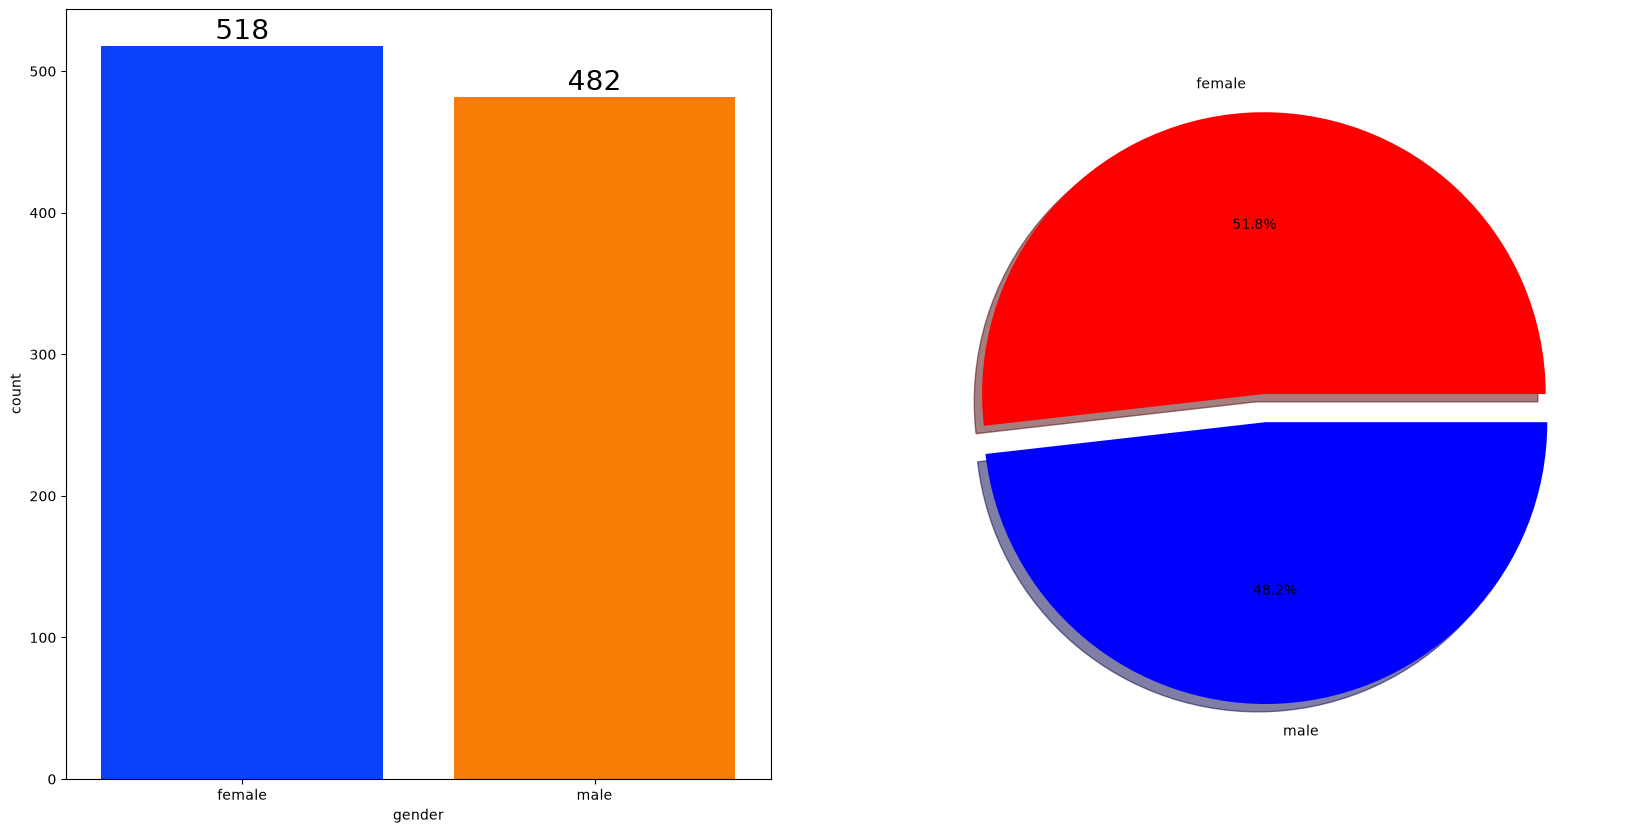

In [25]:
f, ax = plt.subplots(1,2, figsize = (20,10))
sns.countplot(data=df, x = df['gender'], palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

plt.pie(x=df['gender'].value_counts(), labels=['female','male'], explode=[0,0.1], autopct='%1.1f%%', shadow=True, colors = ['red', 'blue'])
plt.show()

### Insights

+ Gender has a balanced data with female students are 518(51.8%) and male students are 484(48.2%)

#### Bivariate Analysis
##### Is gender has any impact on student's performance

In [26]:
gender_group = df.groupby('gender').mean(numeric_only=True)

gender_group

,math_score,reading_score,writing_score,total_score,average_score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


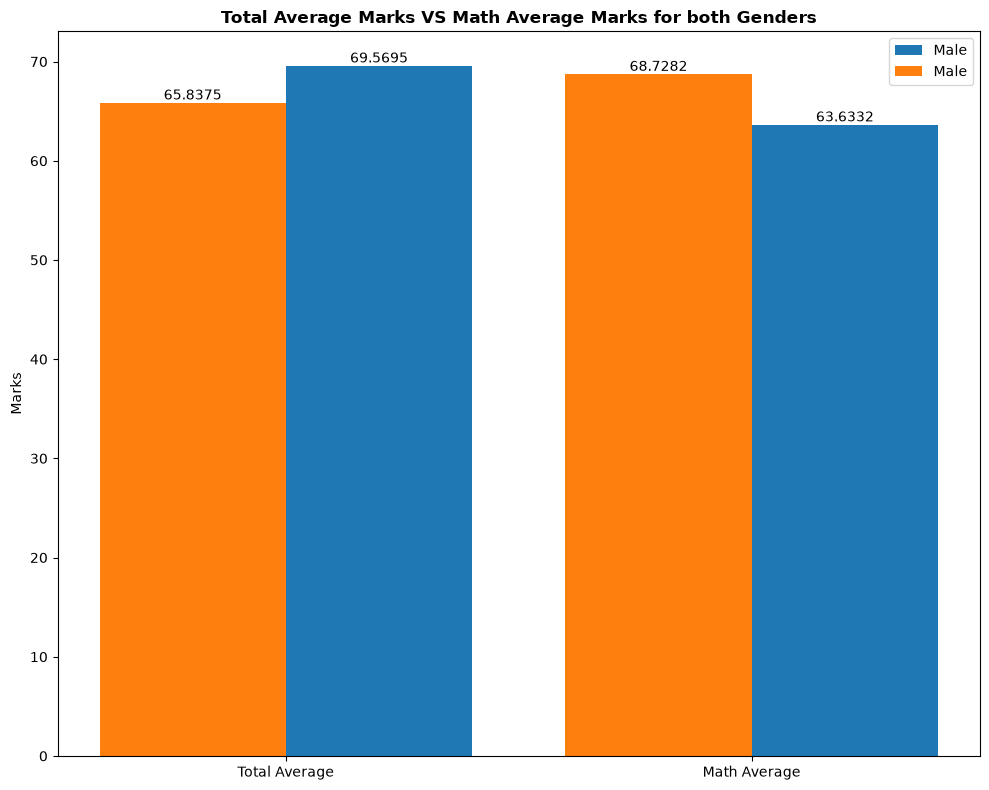

In [27]:
plt.figure(figsize = (10, 8))
x = ['Total Average', 'Math Average']

female_scores = [gender_group['average_score'].iloc[0], gender_group['math_score'].iloc[0]]
male_scores = [gender_group['average_score'].iloc[1], gender_group['math_score'].iloc[1]]

x_axis = np.arange(len(x))

bars1 = plt.bar(x_axis + 0.2, female_scores, 0.4, label = 'Male')
bars2 = plt.bar(x_axis - 0.2, male_scores, 0.4, label = 'Male')

plt.bar_label(bars1, color='black', size=10, fmt='%.4f')
plt.bar_label(bars2, color='black', size=10, fmt='%.4f')

plt.xticks(x_axis, x)
plt.ylabel('Marks')
plt.title("Total Average Marks VS Math Average Marks for both Genders", fontsize = 12, fontweight = 'bold')
plt.legend()
plt.tight_layout()
plt.show()


### Insights

+ On average Female studentshave better overall mean score than males
+ Whereas males have scored higher in Maths

##### 4.4.2) Race/Ethnicity Column

+ How is group wise distribution?
+ Is race has any impact on students performance?

#### Univariate Analysis
##### How is group wise distributed?

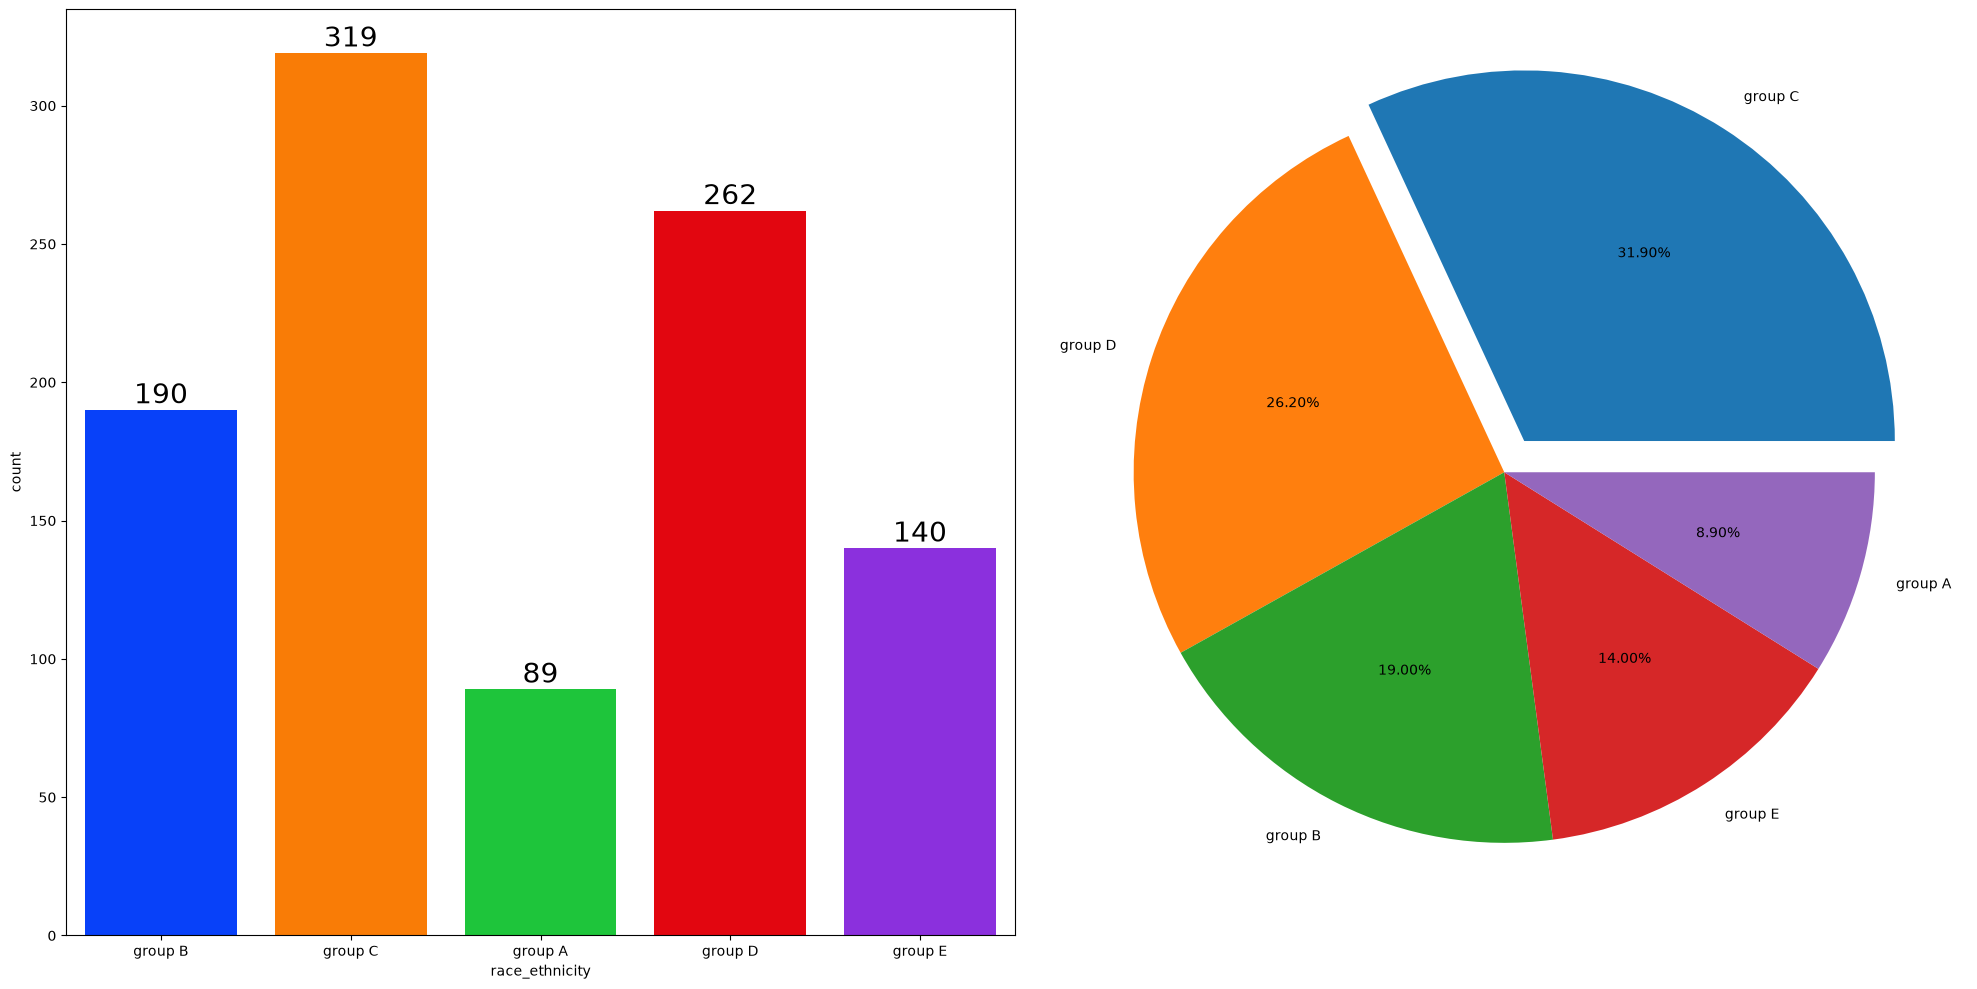

In [28]:
f, ax = plt.subplots(1,2, figsize = (20, 10))
sns.countplot(data = df, x = df['race_ethnicity'], palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)


plt.pie(x = df['race_ethnicity'].value_counts(), labels = df['race_ethnicity'].value_counts().index, explode = [0.1, 0, 0, 0, 0], autopct='%1.2f%%')
plt.tight_layout()
plt.show()

### Insights

+ Most students falls in group C with 319(31.9)%) students and group D with 262(26.20%) students
+ Lowest number of students falls in group A with 89(8.90%) students

### Bivariate Analysis( Is race has any impact on student's performance)

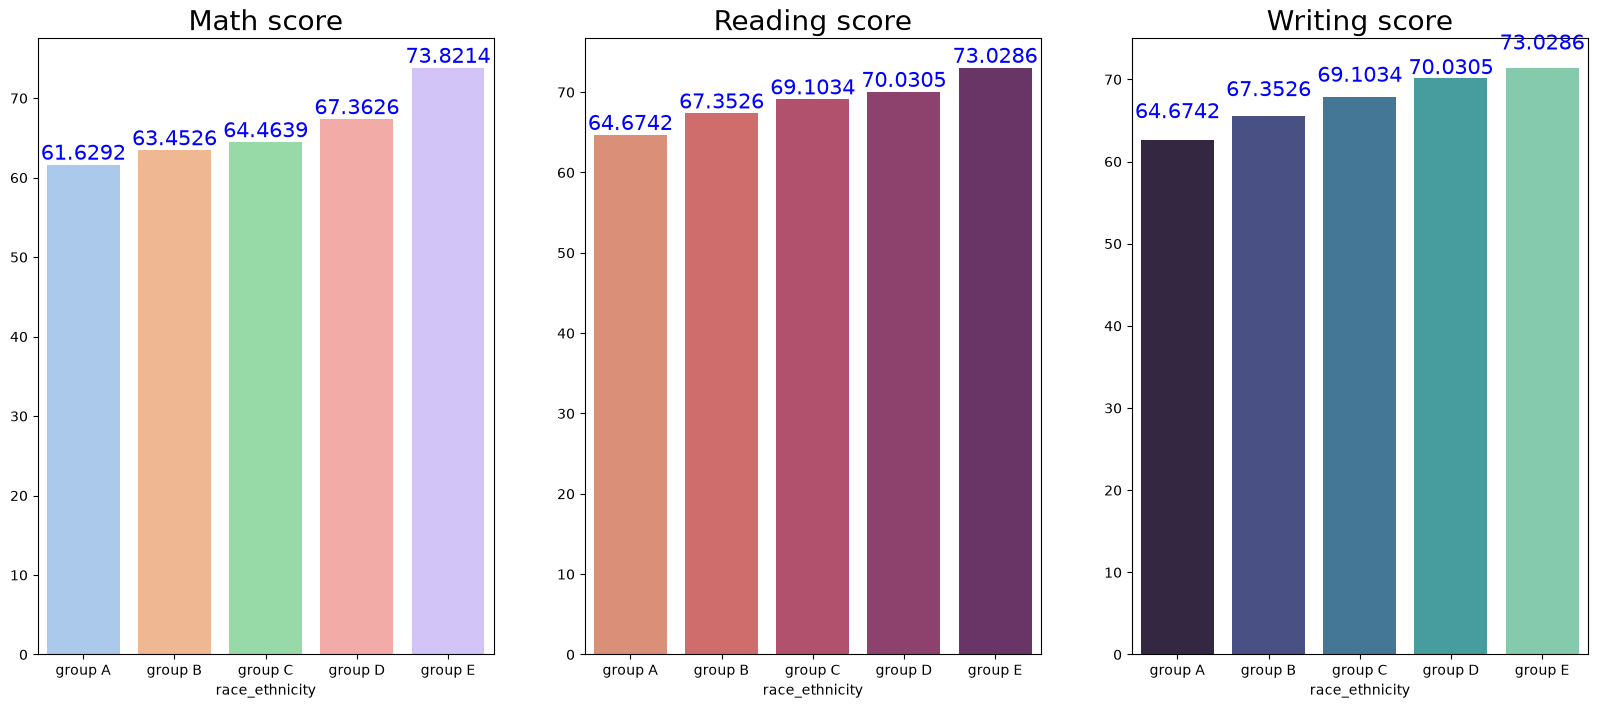

In [29]:
group_data1 = df.groupby('race_ethnicity')

f, ax = plt.subplots(1,3, figsize=(20,8))
sns.barplot(x = group_data1['math_score'].mean().index, y = group_data1['math_score'].mean().values, palette='pastel', ax=ax[0])
ax[0].set_title('Math score', color = 'black', size = 20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='blue', size = 15)

sns.barplot(x = group_data1['reading_score'].mean().index, y = group_data1['reading_score'].mean().values, palette='flare', ax=ax[1])
ax[1].set_title('Reading score', color = 'black', size = 20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='blue', size = 15)


sns.barplot(x = group_data1['writing_score'].mean().index, y = group_data1['writing_score'].mean().values, palette='mako', ax = ax[2])
ax[2].set_title('Writing score', color = 'black', size = 20)

for container in ax[1].containers:
    ax[2].bar_label(container, color='blue', size = 15)

### Insights

+ Group E students have scored the highest marks
+ Group A students have scired the lowest marks
+ Students from a lower Socioeconomic status have a lower avergae in all course subjects

### 4.4.3 Parental level of education column

+ What is educational background of student's parent?
+ Is parental education has any impact on student's performance?

## Univariate Analysis ( What is educatonal background of student's parent?)

findfont: Failed to find font weight 30, now using 400.


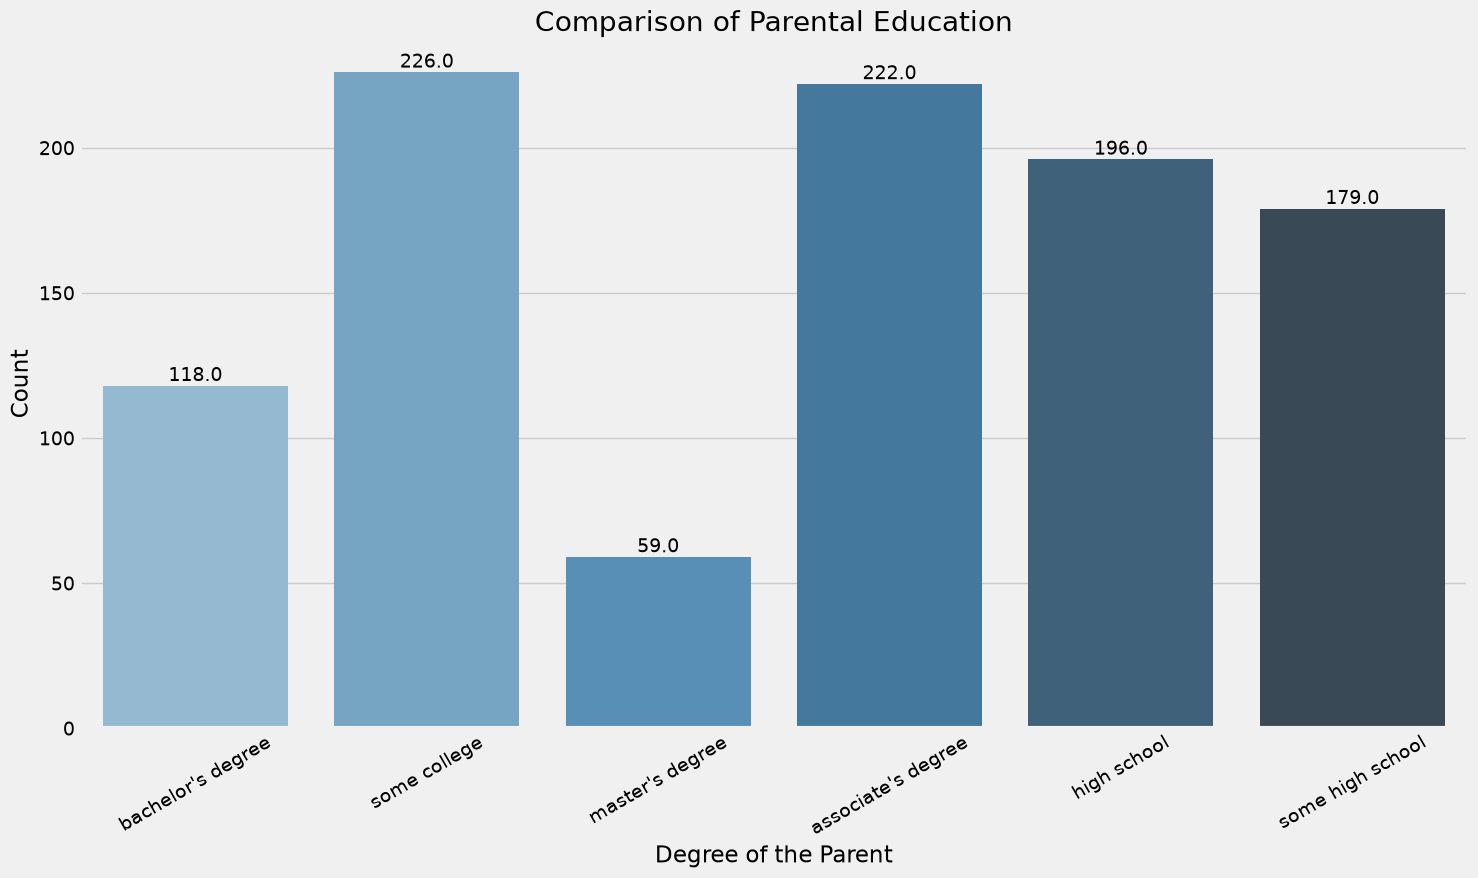

In [30]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use("fivethirtyeight")
ax = sns.countplot(data = df, x = 'parental_level_of_education', palette = "Blues_d")
plt.title("Comparison of Parental Education", fontweight = 30, fontsize = 20)
plt.xlabel('Degree of the Parent')
plt.xticks(rotation=30) 
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

### Insight

+ Largest number of parents are from some college

### Multivariate Analysis( Is parental education has any impact on student's performance?)

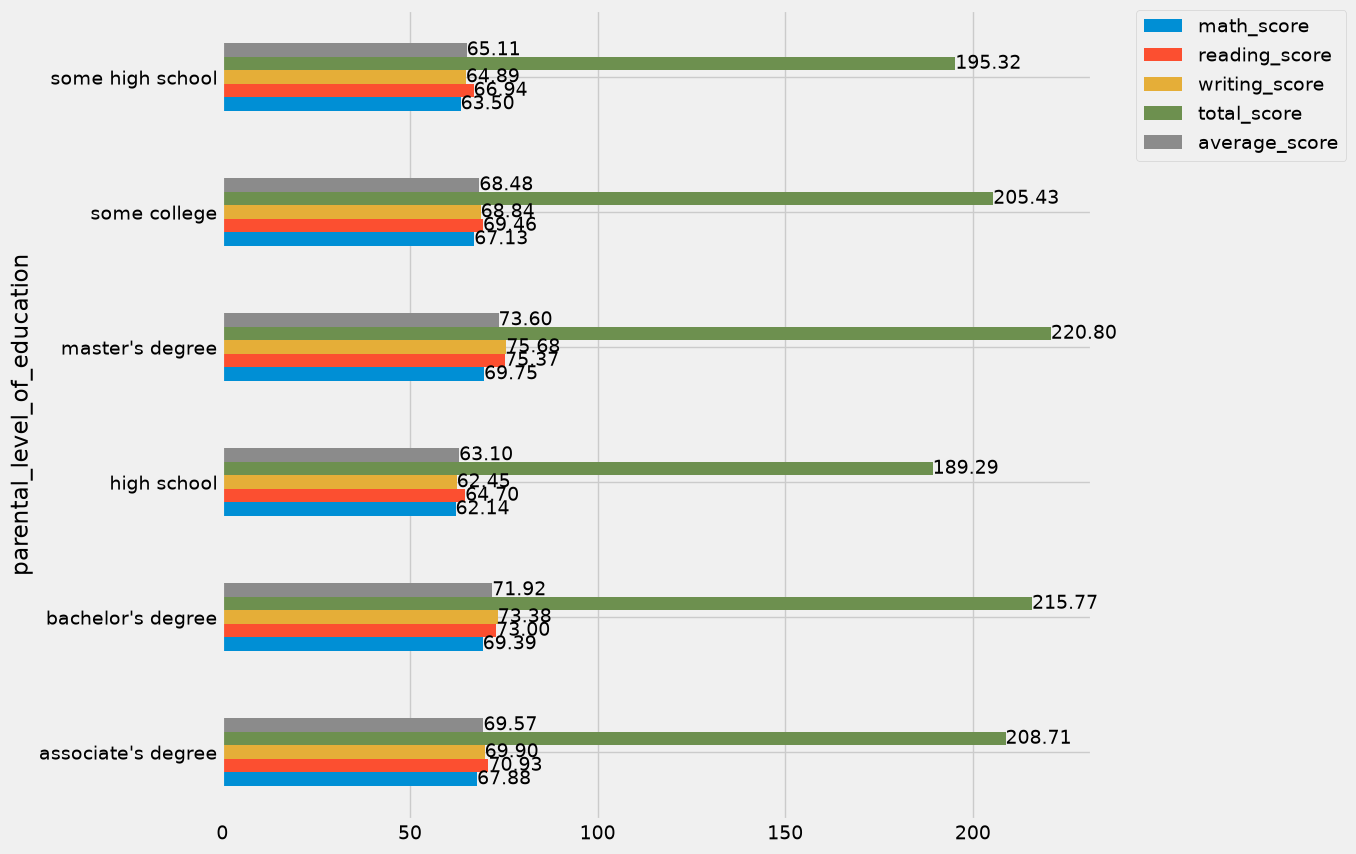

In [31]:
ax = df.groupby("parental_level_of_education").agg('mean', numeric_only = True).plot(kind='barh', figsize=(10,10))
plt.legend(bbox_to_anchor = (1.05,1), loc = 2, borderaxespad=0.)

for container in ax.containers:
    ax.bar_label(container, fmt = '%.2f')

plt.show()

### Insights

+ The score of students whose parents possess master and bachelor level of education are higher than others

## 4.4.4) Lunch column

+ Which type of lunch is most common among students?
+ What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common among students?)

findfont: Failed to find font weight 30, now using 400.


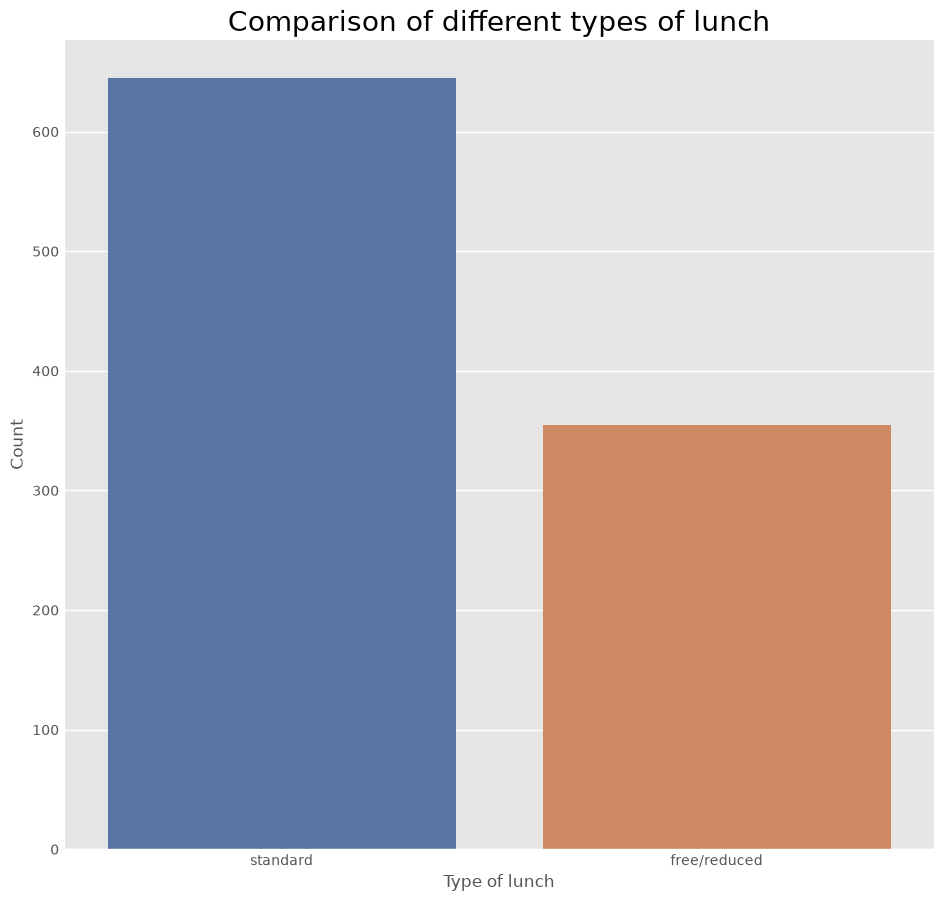

In [32]:
plt.rcParams['figure.figsize'] = (10, 10)
plt.style.use('ggplot')
sns.countplot(data = df,  x = 'lunch', palette='deep')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('Type of lunch')
plt.ylabel('Count')
plt.show()

### Insight

+ Students been served Standard lunch was more than free lunch

### Bivariate Analysis ( Is lunch type intake has impact on student's performance)

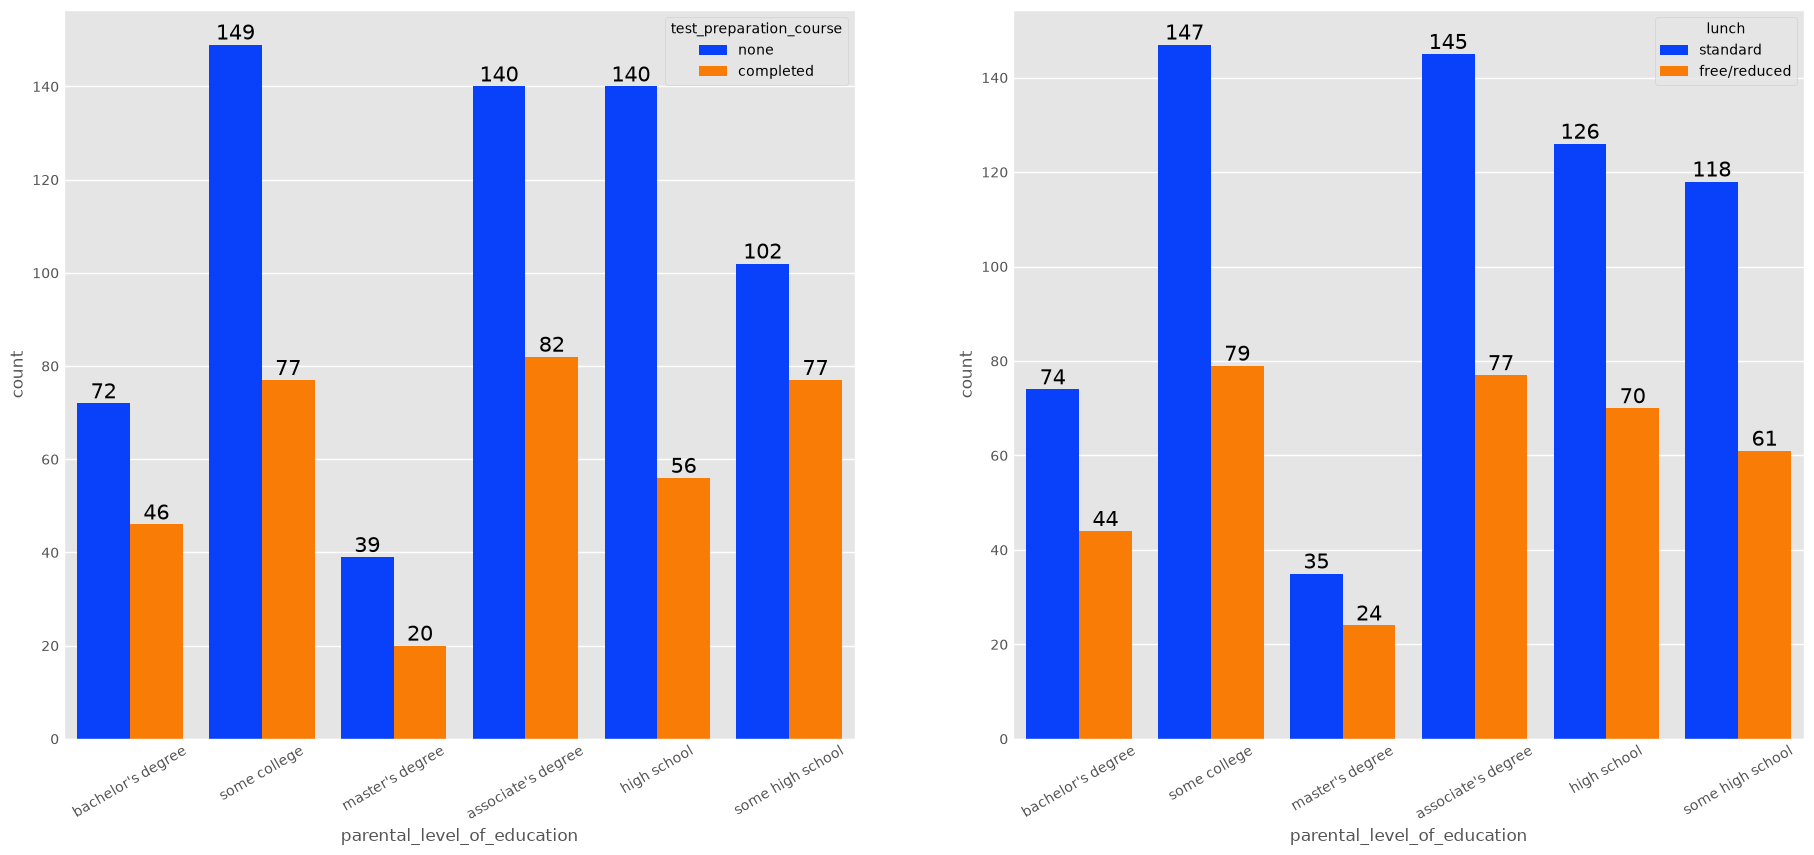

In [33]:
f, ax = plt.subplots(1,2, figsize = (20,9))
sns.countplot(data = df, x = df['parental_level_of_education'], palette='bright', hue = 'test_preparation_course', saturation = 0.95, ax = ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 15)
    ax[0].tick_params(axis='x', rotation=30)

sns.countplot(data = df, x = df['parental_level_of_education'], palette='bright', hue = 'lunch', saturation = 0.95, ax = ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, color = 'black', size = 15)
    ax[1].tick_params(axis='x', rotation=30)

### Insights

+ Students who get Stnadrd lunch tend to perform better than students who got free/reduced lunch

### 4.4.5) Test preparation course 

+ Which type of lunch is most common among students?
+ Is the test preparation has any impact on student's performace?

## Bivariate Analysis (Is test preparation course has any impact on student's performance)

<Axes: xlabel='lunch', ylabel='writing_score'>

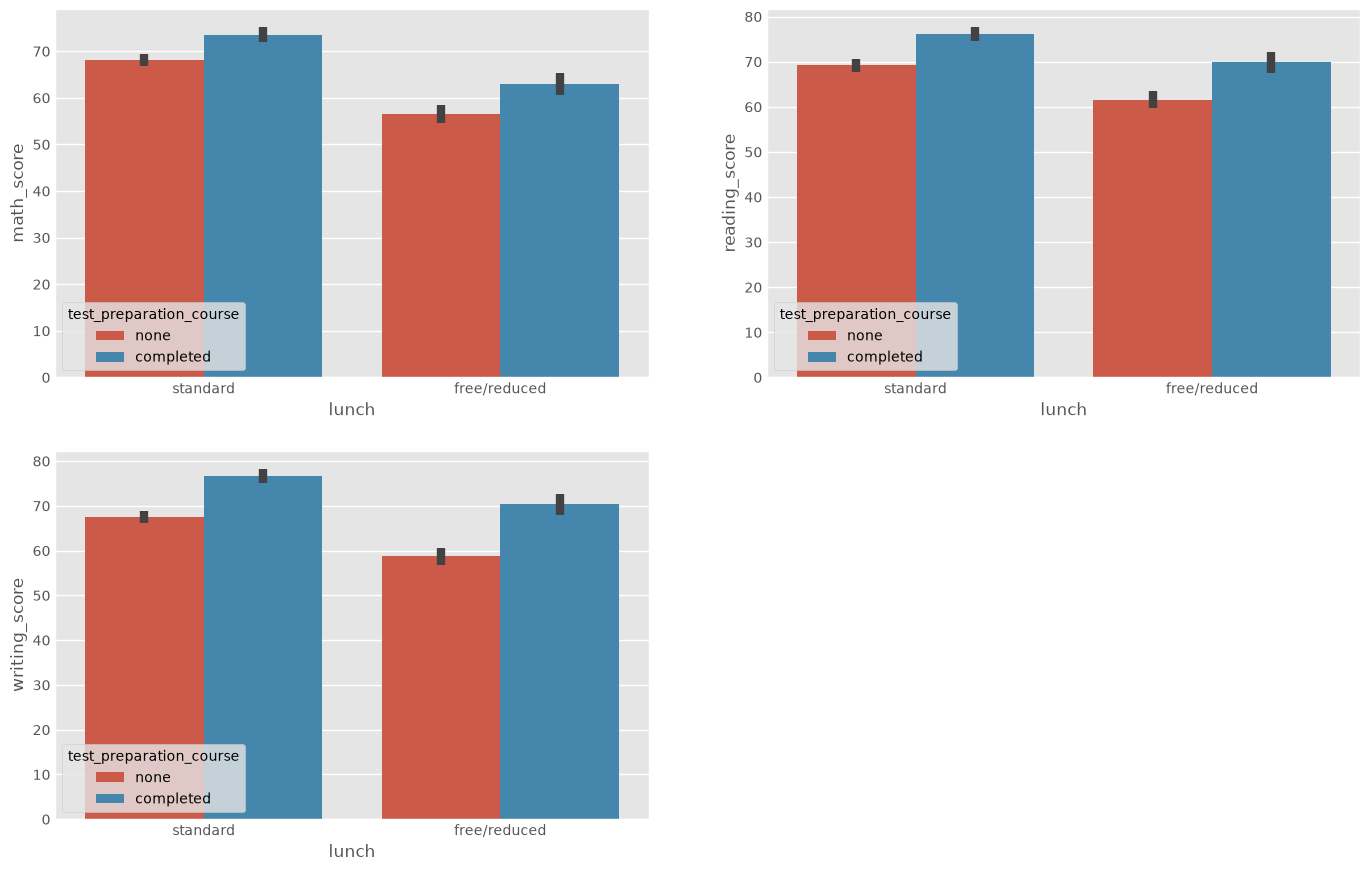

In [34]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.barplot(x = df['lunch'], y = df['math_score'], hue = df['test_preparation_course'])

plt.subplot(2,2,2)
sns.barplot(x = df['lunch'], y = df['reading_score'], hue = df['test_preparation_course'])

plt.subplot(2,2,3)
sns.barplot(x = df['lunch'], y = df['writing_score'], hue = df['test_preparation_course'])

### Insights

+ Students who have completed the test preparation course have higher scores higher in all three categories than those who haven't taken the course

### 4.4.6) Checking Outliers

<Axes: ylabel='average_score'>

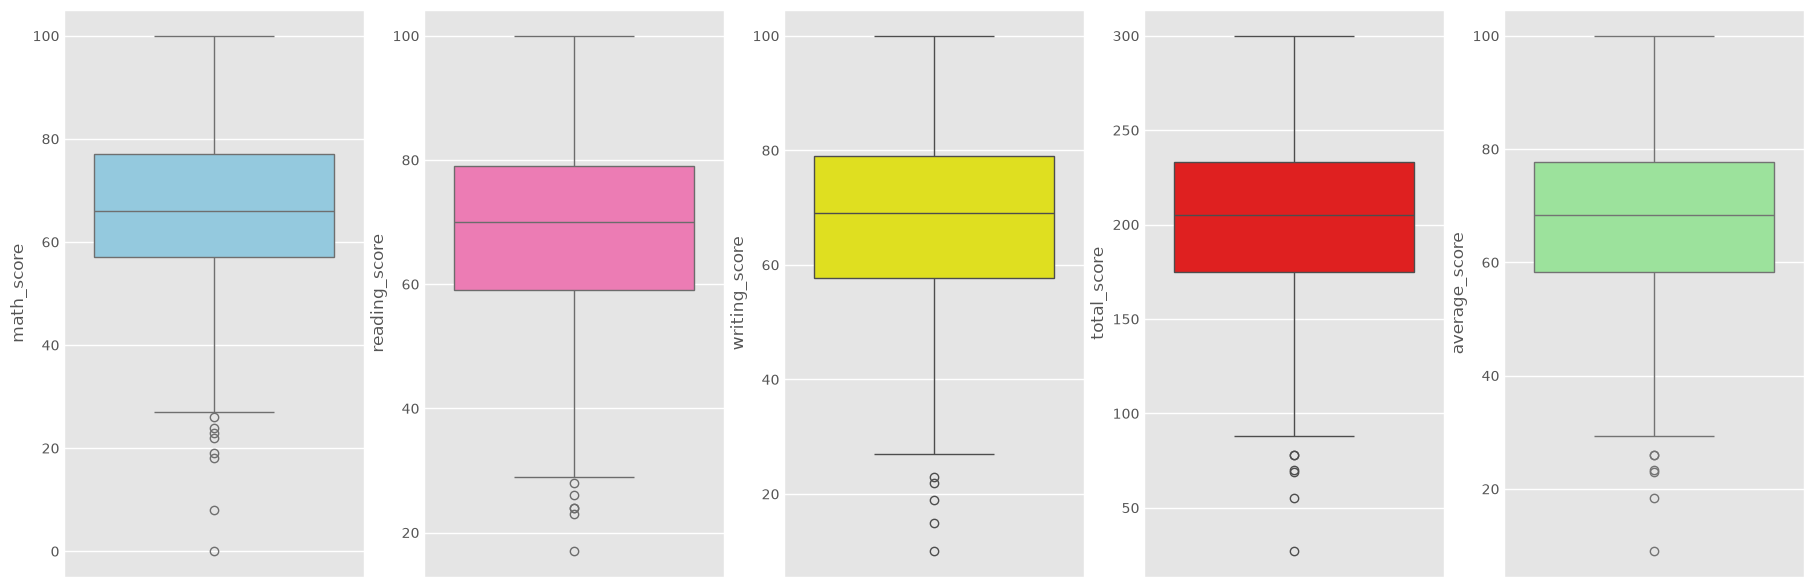

In [35]:
plt.subplots(1,5, figsize=(20,7))
plt.subplot(151)
sns.boxplot(df['math_score'], color = 'skyblue')

plt.subplot(152)
sns.boxplot(df['reading_score'], color = 'hotpink')

plt.subplot(153)
sns.boxplot(df['writing_score'], color = 'yellow')

plt.subplot(154)
sns.boxplot(df['total_score'], color = 'red')

plt.subplot(155)
sns.boxplot(df['average_score'], color = 'lightgreen')

#plt.tight_layout()
#lt.show()

### 4.4.7) Multivariate analysis using pairplot

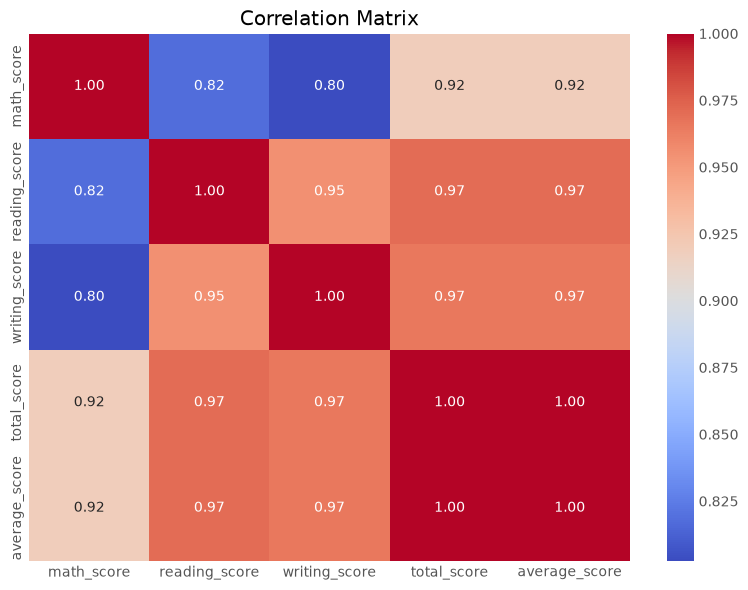

In [36]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

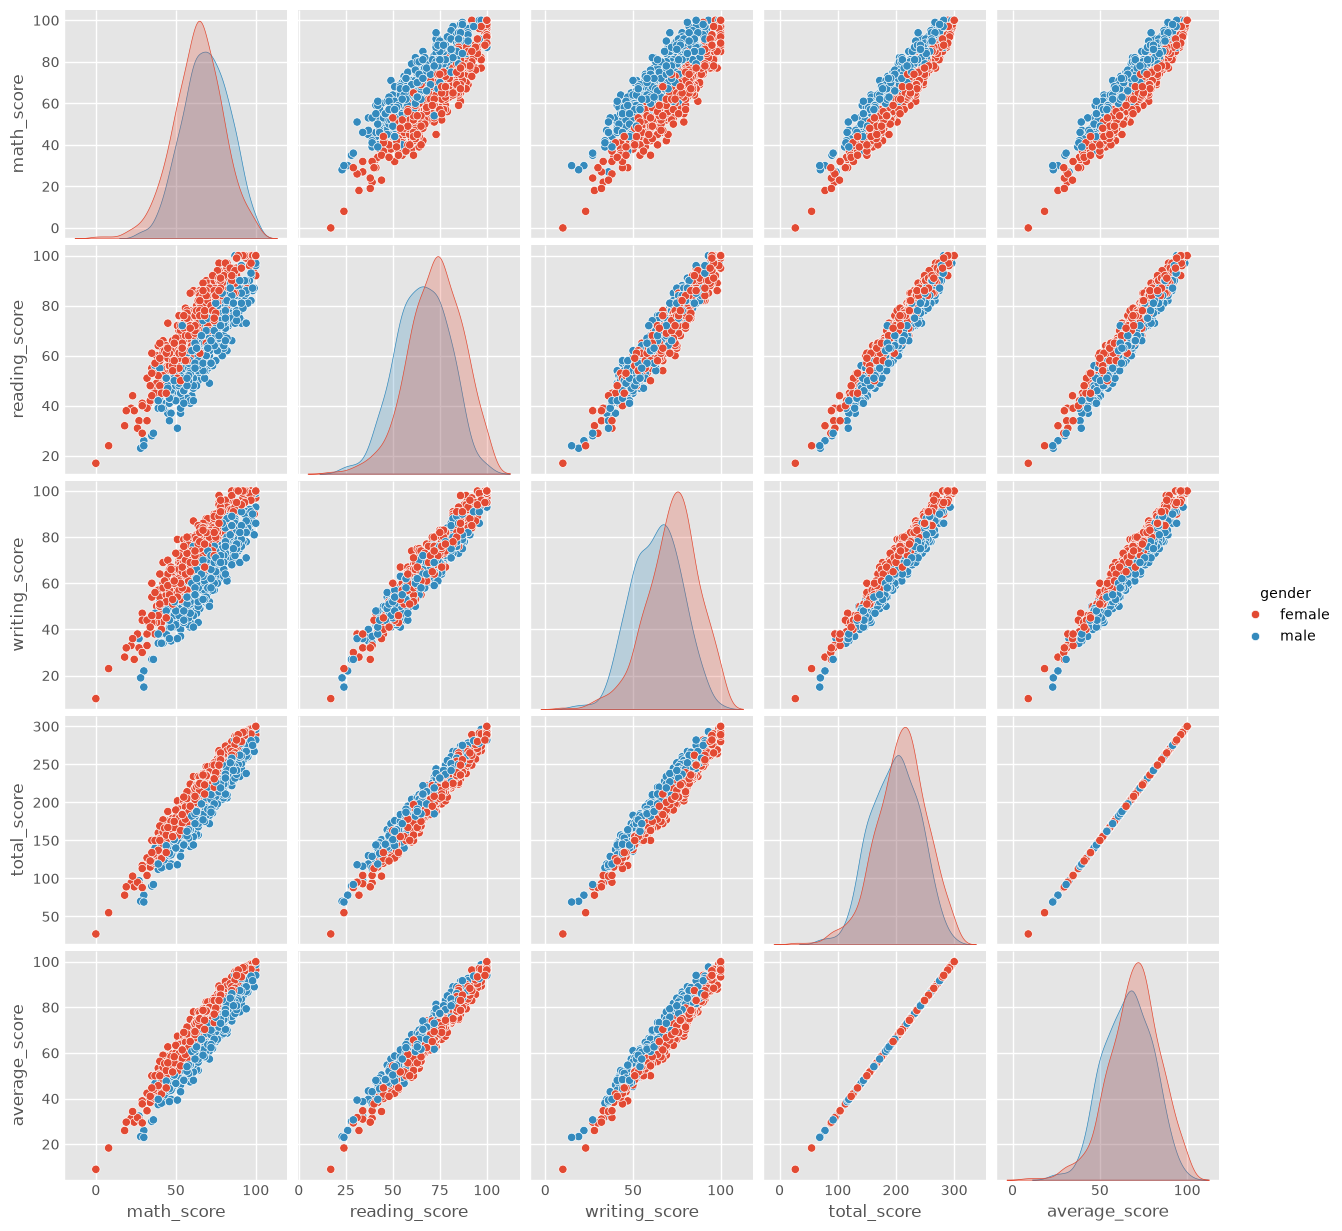

In [37]:
sns.pairplot(df, hue = 'gender')
plt.show()

### Insights

+ From the above plot it is clear that all the scores increase lnaerly with each other

## 5) Conclusions

+ Student's performance is related with lunch, race, parental level of education
+ Females lead in pass percentage and also are top scorers
+ Student;s performance is not much related with test preparation course
+ Finishing preparaton course is benefitial